In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Compare splice junctions predicted from RNAseq data in Mesodinium (and Teleaulax) to (1) other litostome ciliates and (2) other eukaryotes that are known to have few introns and reduced spliceosomes.

We require reference genome assembly and available RNAseq data from the same species. The reference genome should ideally be from a cultivated strain, but for the litostome ciliates apart from Mesodinium, the only available strain genomes are for Balantidium ctenopharyngodoni (order Entodiniomorphida) and Entodinium caudatum (order Vestibuliferida). The remaining genomes are from whole-genome amplification libraries of isolated cells. We chose two such genomes where conspecific RNAseq was available: Isotricha intestinalis (Vestibuliferida) and Diplodinium dentatum (Entodiniomorphida).

A [recent study](https://doi.org/10.1186/s12915-024-01904-2) published single-cell genomes from subclass Haptoria. Raw reads, though not the assemblies, are available (https://ngdc.cncb.ac.cn/gsa/search?searchTerm=PRJCA019558). However, the single-cell transcriptomes they used were produced by [another study](https://doi.org/10.1016/j.ejop.2024.126062), and although a BioProject has been registered (https://www.ncbi.nlm.nih.gov/bioproject/1012847), the read data are not yet published (as of 24 May 2024).

Enterocytozoon bieneusi: No public RNAseq data found on SRA. Publications that reported lack of introns only performed genome sequencing (https://doi.org/10.1371%2Fjournal.ppat.1000261, https://doi.org/10.1093%2Fgbe%2Fevq022) and used homology- and modeling based methods for intron detection, so we could not include them in our current analysis.

Pseudoloma neurophilia: Mapped libraries SRR24416341 and SRR24416342 to reference genome GCA_001432165.1, but mapping rate was only 0.14%. Decided to exclude this for now because insufficient data.

Summary so far:

* Splice junctions in Mrub RNAseq mappings appear to be artefacts because:
  * Majority are not bound by canonical or semi-canonical splice site motifs
  * No obvious length peak, just slopes down from minimum length cutoff
  * Enrichment in 3n lengths is typical of indels
  * CHECK: Hamming distances of flanking regions should indicate which ones are mapping to repeat regions
* Sequences in the same libraries that map to Tamp genome are a technical sanity check: These have splice junctions that represent introns of the expected size range and splice site motifs. Unlikely that there was some technical issue with the RNAseq library that would only affect the Mrub sequences.
* Splice junctions in RNAseq from other litostomes have expected characteristics of introns: Majority with canonical GT-AG splice site motif, distinct peak in length distribution. However there are also spurious junctions: enrichment of 3n sequences, absence of canonical splice site motif, low Hamming distance with flanking sequence
* Unusually high enrichment of 3n splice junctions in Ecau, Dden: these are mostly mapped to repeat regions, and largely eliminated when filtered by Hamming distance metric.
* Are gene predictions from other studies without conspecific transcriptomic data reliable?
* Even if transcriptomic data were available, there are signs of misparameterized gene models in other published annotations, at least where introns are concerned
  * Balantidium ctenopharyngodoni: only a few dozen introns in published annotation, whereas RNAseq suggests at least a few hundred
  * Entodinium caudatum: abrupt lower cutoff in intron length distribution in the published annotation, suggest that a hard cutoff was applied that filtered out true introns.

## Candidate splice junction metrics

In [4]:
ls ../portcullis

filter/     prep.avis/  prep.dden/  prep.ecun/  prep.lox1/  prep.rlon/
junc/       prep.bcte/  prep.did1/  prep.epi1/  prep.mosp/  prep.sp10/
prep.amp2/  prep.cmer/  prep.dim2/  prep.epi2/  prep.mrub/  prep.ssta/
prep.asch/  prep.dcos/  prep.ecau/  prep.iint/  prep.pneu/  prep.tamp/


In [29]:
candidates = [
    'mrub','ecau','bcte','dden','iint','mosp',
    'amp2','asch','avis','dcos','did1','dim2','epi1','epi2','lox1','rlon','sp10','ssta',
    'tamp',
    'cmer','ecun','pneu'
]

In [30]:
juncs = {}
for sp in candidates:
    juncs[sp] = pd.read_table(f"../portcullis/junc/{sp}.junctions.tab", sep="\t")
    juncs[sp]['size3n'] = juncs[sp]['size'].apply(lambda x: x%3 == 0)
    juncs[sp]['source'] = sp
df_all = pd.concat(juncs.values())
df_all['hamming_min'] = df_all[['hamming3p','hamming5p']].min(axis=1)

In [31]:
df_all['source'].value_counts()

source
tamp    509390
mosp    504785
mrub    481811
ssta     35827
dcos     34193
ecau     33090
cmer     26214
dim2     24025
epi1     23541
iint     21555
bcte     18411
epi2     18267
avis     18148
rlon     17256
asch     16734
sp10     14173
did1     13712
dden      8581
lox1      7502
amp2      4407
ecun      2163
pneu       380
Name: count, dtype: int64

In [36]:
df_all.groupby('source')['canonical_ss'].value_counts().reset_index().pivot(
    index="source",columns="canonical_ss",values="count"
)

canonical_ss,C,N,S
source,,,
amp2,2513,1779,115
asch,7627,8356,751
avis,12852,4565,731
bcte,10565,7053,793
cmer,19086,6159,969
dcos,26099,7231,863
dden,4330,4053,198
did1,7651,5429,632
dim2,11273,11264,1488


In [33]:
df_all.groupby('source')['mean_mismatches'].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
amp2,4407.0,1.467049,4.022037,0.0,0.097392,0.520833,1.501910,95.9006
asch,16734.0,1.845221,3.611177,0.0,0.333333,1.000000,2.000000,96.6311
avis,18148.0,1.171041,2.121566,0.0,0.100000,0.600000,1.416670,49.6632
bcte,18411.0,1.668835,4.667511,0.0,0.062500,0.689189,1.814690,111.6590
cmer,26214.0,1.848572,3.186670,0.0,0.230928,1.000000,2.000000,72.1801
dcos,34193.0,1.122327,1.897183,0.0,0.000000,0.666667,1.428570,64.2857
dden,8581.0,1.369762,2.316058,0.0,0.282051,1.000000,1.799280,47.0264
did1,13712.0,1.835178,4.134470,0.0,0.166667,1.000000,2.000000,76.6933
dim2,24025.0,1.312088,3.374606,0.0,0.000000,0.333333,1.500000,113.1540


In [34]:
df_all.groupby('source')['nb_rel_aln'].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
amp2,4407.0,62.304062,501.168646,0.0,0.0,2.0,19.0,16626.0
asch,16734.0,53.670790,710.498558,0.0,0.0,1.0,9.0,41210.0
avis,18148.0,26.139189,312.239756,0.0,0.0,2.0,9.0,34224.0
bcte,18411.0,40.076748,202.135350,0.0,1.0,2.0,16.0,10331.0
cmer,26214.0,9.921263,70.139101,0.0,1.0,1.0,2.0,3415.0
dcos,34193.0,12.374082,98.506333,0.0,0.0,1.0,4.0,8733.0
dden,8581.0,59.648759,420.706425,0.0,1.0,4.0,23.0,20615.0
did1,13712.0,70.177509,2319.116540,0.0,0.0,2.0,12.0,267486.0
dim2,24025.0,37.980187,570.646268,0.0,0.0,2.0,9.0,67218.0


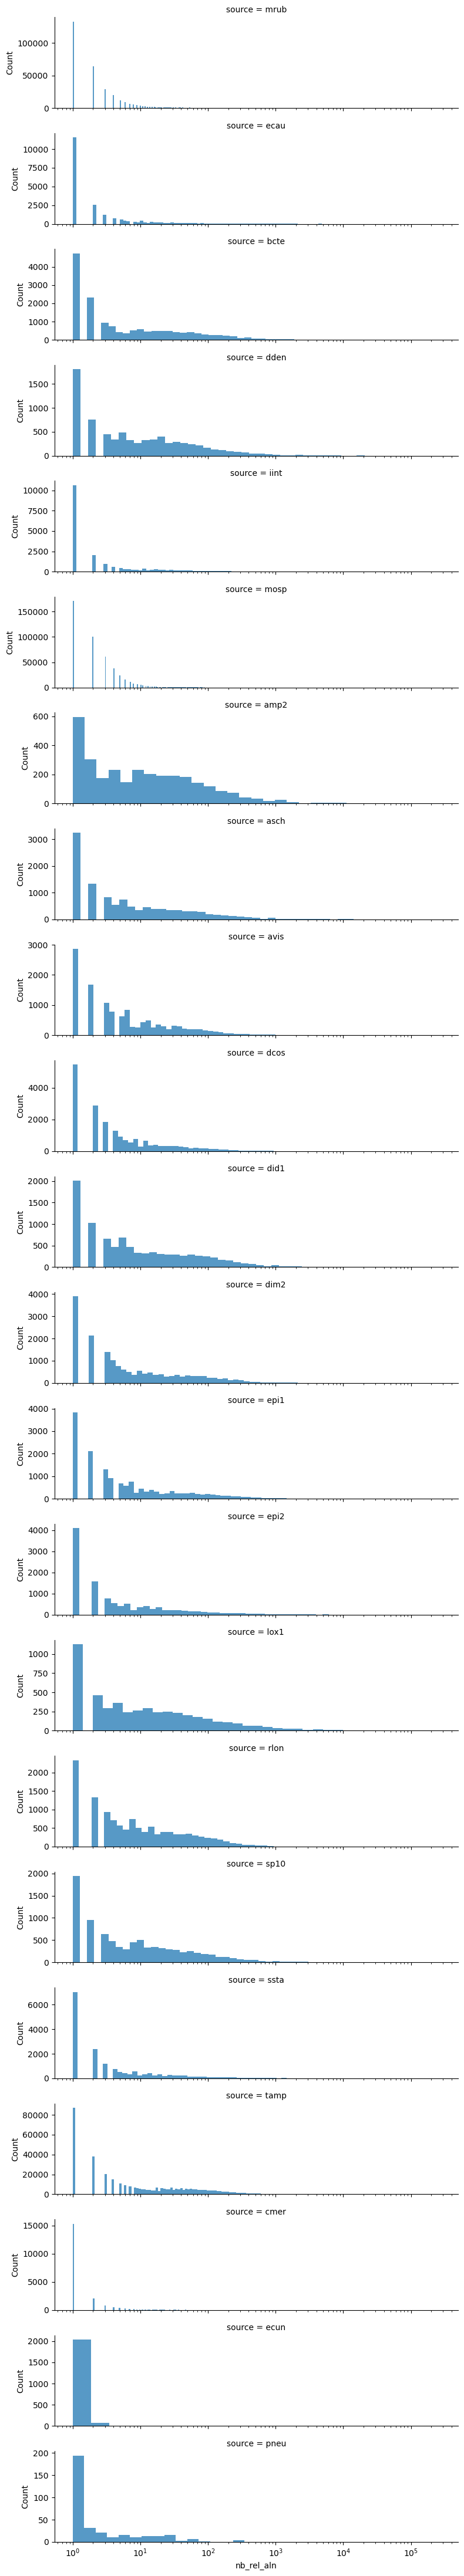

In [37]:
g = sns.FacetGrid(
    data=df_all,
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='nb_rel_aln',
    log_scale=True, linewidth=0,
)#.set(yscale='log')
g.savefig("portcullis.nb_rel_aln.histogram.pdf")
g.savefig("portcullis.nb_rel_aln.histogram.png")

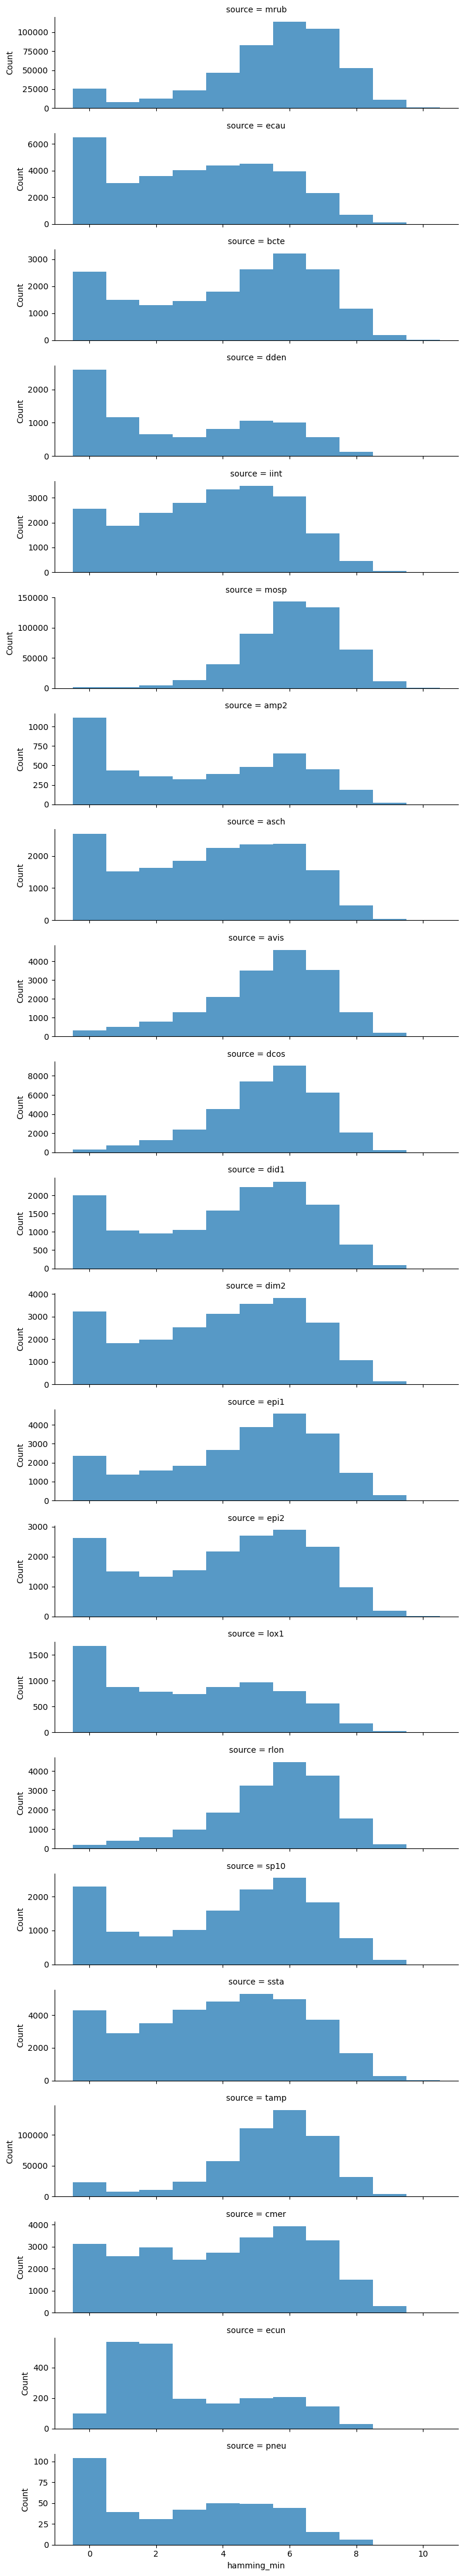

In [38]:
# Histogram of Hamming distances

g = sns.FacetGrid(
    data=df_all,
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='hamming_min', linewidth=0, discrete=True
)
g.savefig("portcullis.hamming_min.histogram.pdf")
g.savefig("portcullis.hamming_min.histogram.png")

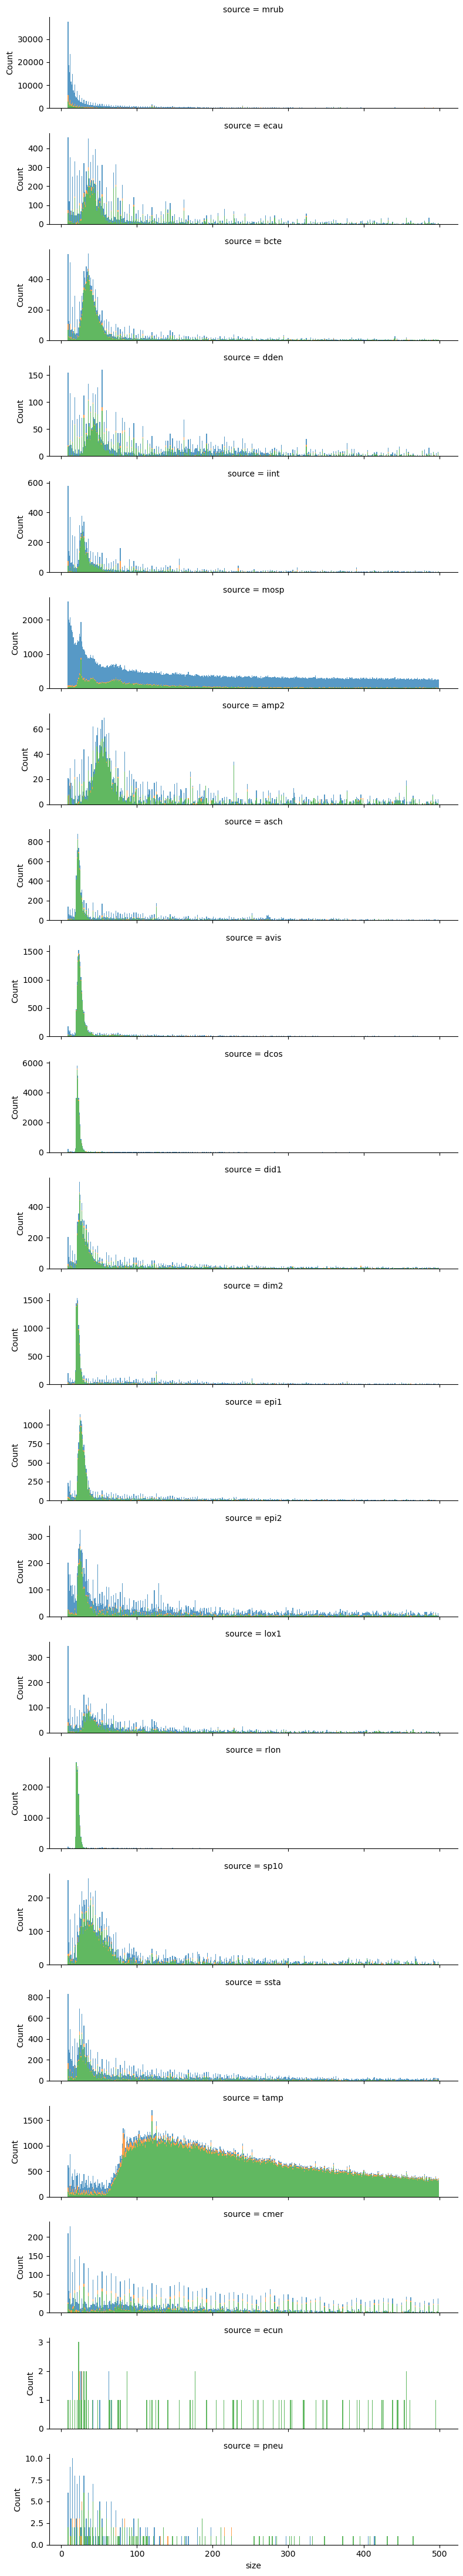

In [39]:
g = sns.FacetGrid(
    data=df_all.query('size<500'),
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='canonical_ss', hue_order=['N','S','C'],
    discrete=True, multiple='stack', linewidth=0,
)
g.savefig("portcullis.intron_size.by_canonical.pdf")
g.savefig("portcullis.intron_size.by_canonical.png")

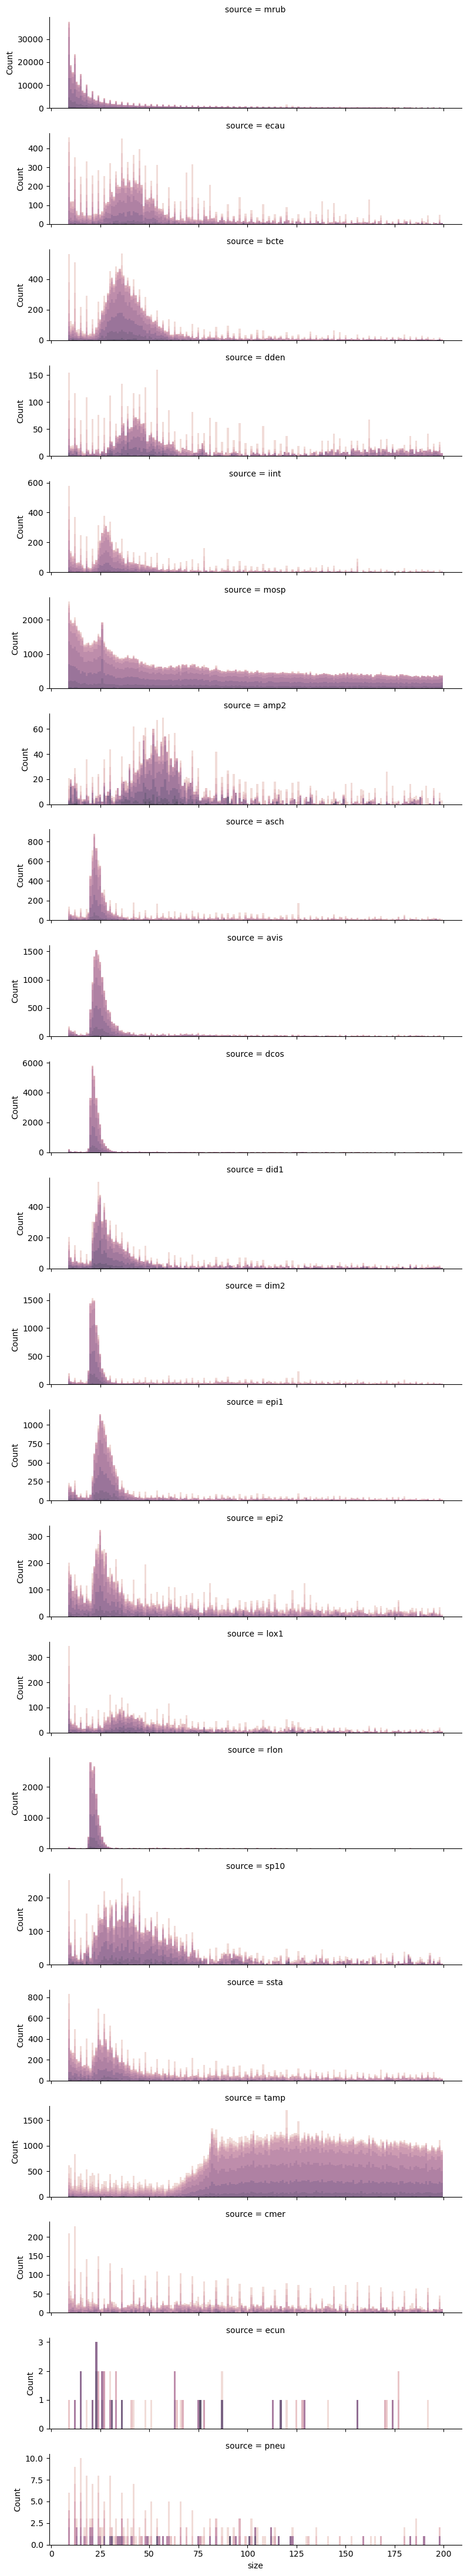

In [40]:
g = sns.FacetGrid(
    data=df_all.query('size<200'),
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='hamming_min',
    discrete=True, multiple='stack', linewidth=0,
)
g.add_legend()
g.savefig("portcullis.intron_size.max_200.by_hamming_min.pdf")
g.savefig("portcullis.intron_size.max_200.by_hamming_min.png")

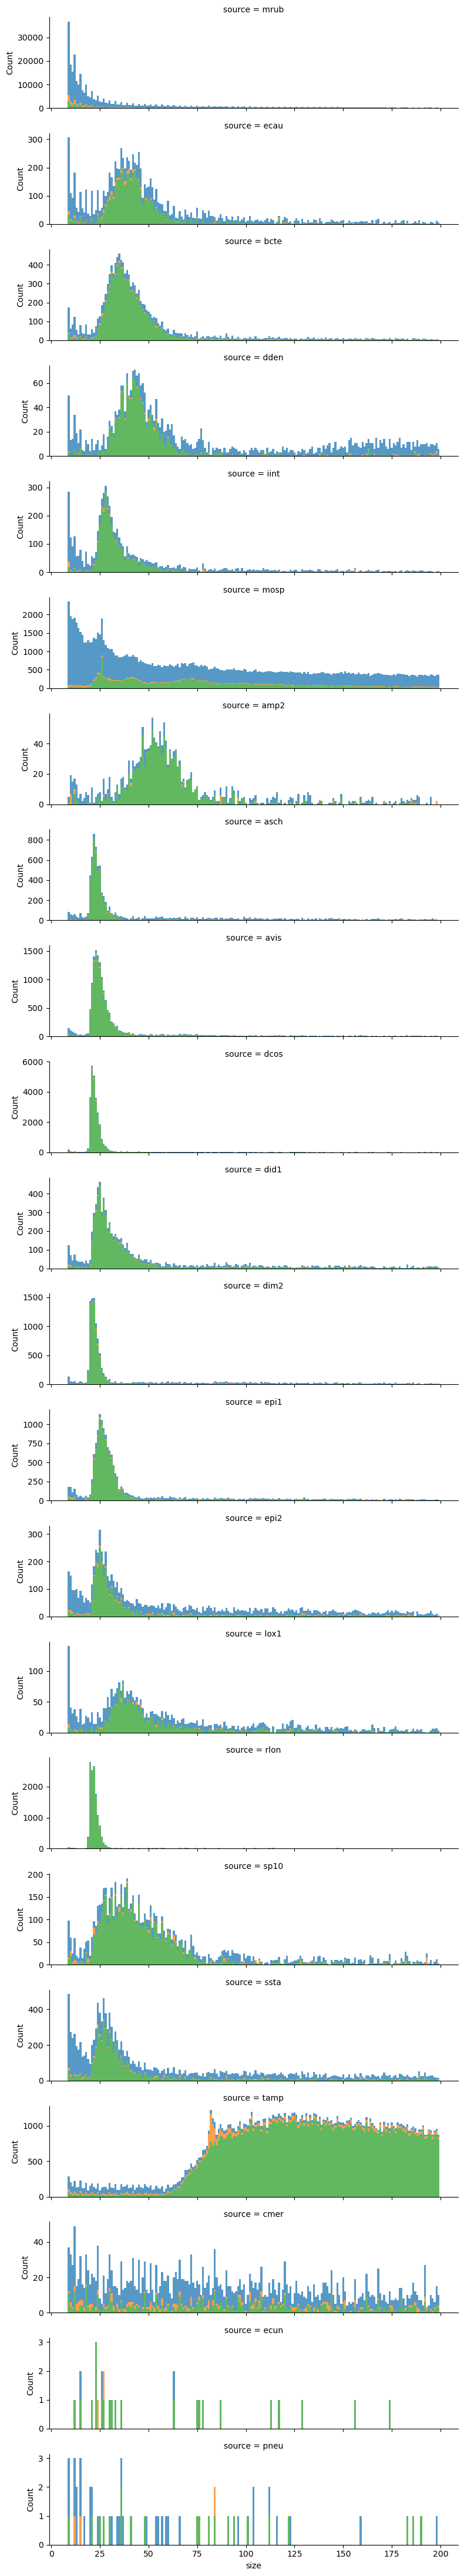

In [41]:
g = sns.FacetGrid(
    data=df_all.query('size<200 and hamming_min > 2'),
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='canonical_ss', hue_order=['N','S','C'],
    discrete=True, multiple='stack', linewidth=0,
)
g.savefig("portcullis.intron_size.max_200.hamming_min_2.by_canonical.pdf")
g.savefig("portcullis.intron_size.max_200.hamming_min_2.by_canonical.png")

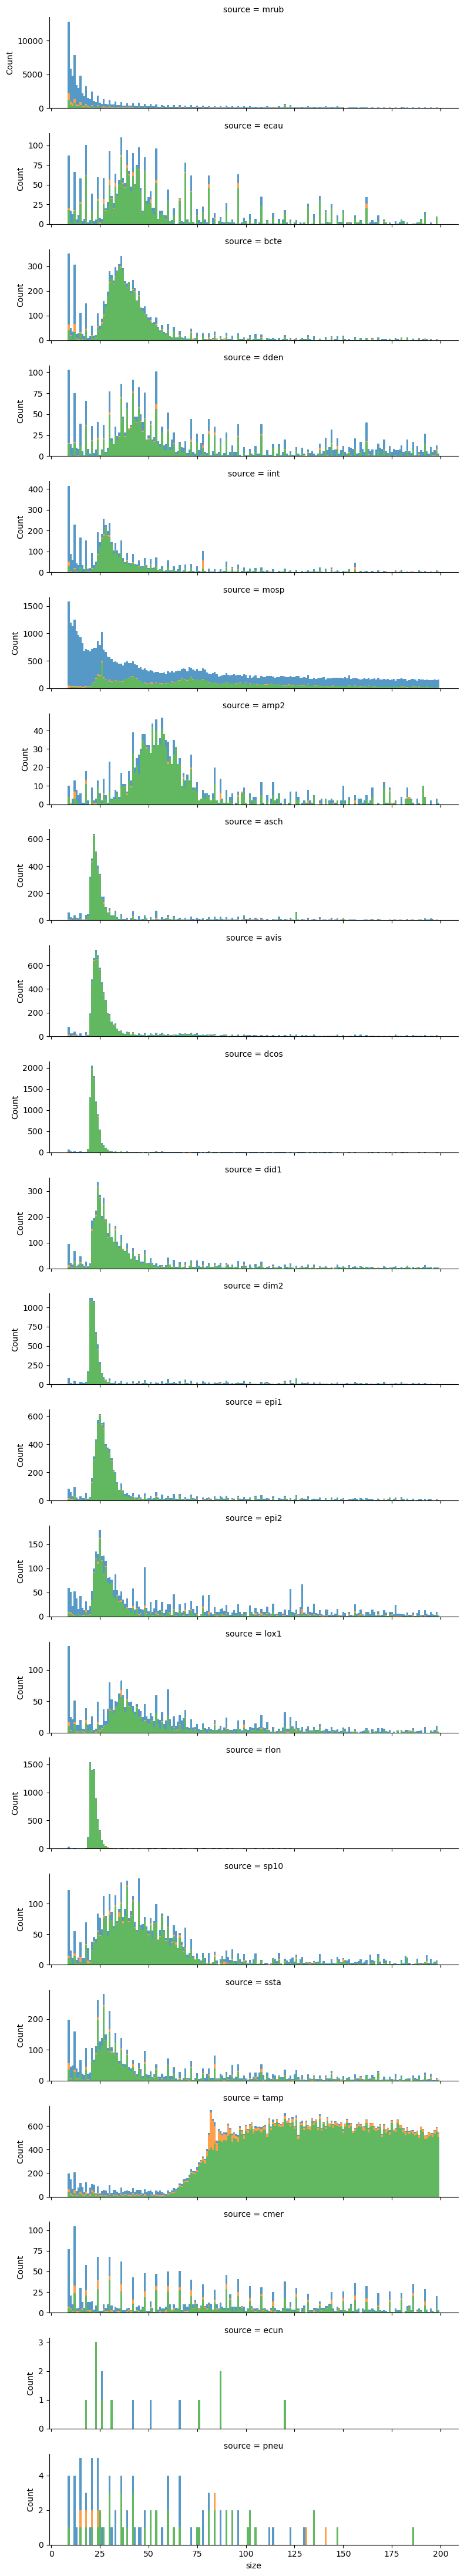

In [42]:
g = sns.FacetGrid(
    data=df_all.query('size<200 and nb_rel_aln > 2'),
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='canonical_ss', hue_order=['N','S','C'],
    discrete=True, multiple='stack', linewidth=0,
)
g.savefig("portcullis.intron_size.max_200.nb_rel_aln_min_2.by_canonical.pdf")
g.savefig("portcullis.intron_size.max_200.nb_rel_aln_min_2.by_canonical.png")

In [53]:
df_all.query('size<200').groupby(
    ['source', 'canonical_ss']
)['nb_rel_aln'].describe().to_csv(
    "portcullis.summarize_nb_rel_aln.by_canonical_ss.csv"
)

Exclude splice junctions supported by <= 2 reads, which are likely to be sequencing errors.

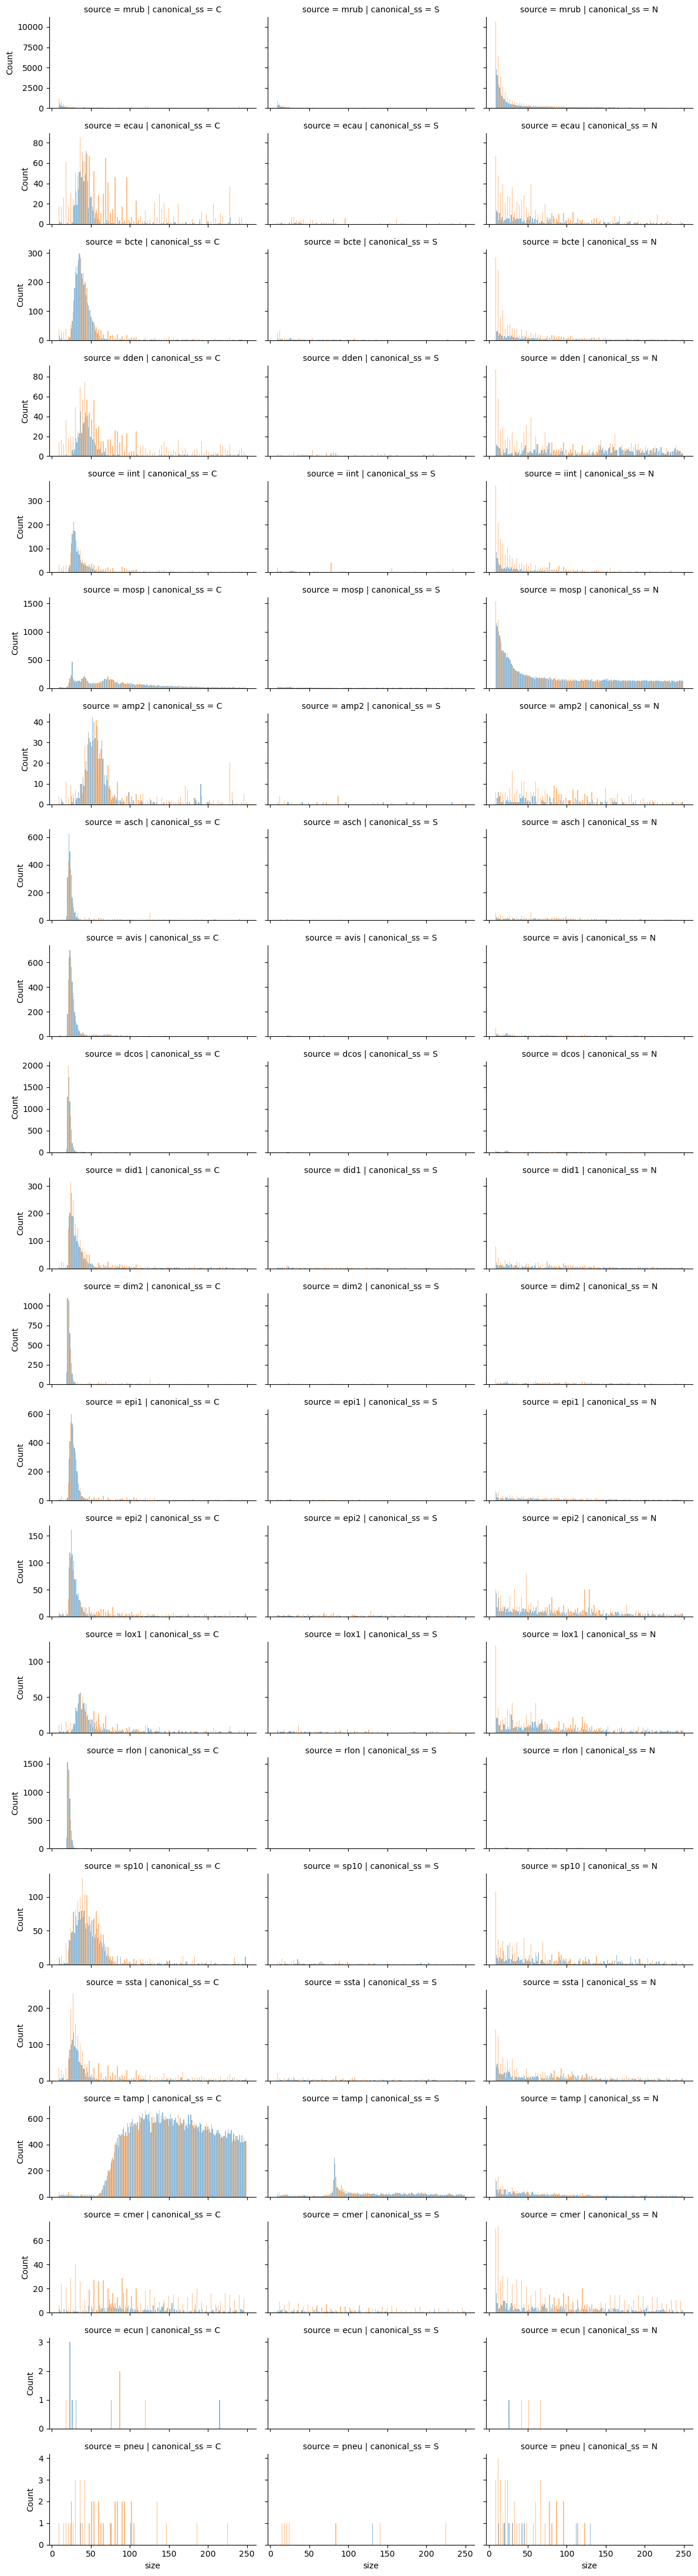

In [44]:
g = sns.FacetGrid(
    data=df_all.query('size<250 and nb_rel_aln > 2'),
    row='source', col='canonical_ss', col_order=['C','S','N'],
    aspect=2, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='size3n', hue_order=[False,True],
    discrete=True, linewidth=0,
)

g.savefig("portcullis.intron_size.max_250.nb_rel_aln_min_2.facet_by_canonical.pdf")
g.savefig("portcullis.intron_size.max_250.nb_rel_aln_min_2.facet_by_canonical.png")

The M. rubrum library has much higher coverage than the other RNAseq libraries applied here. If the genome indeed has introns but only a few, their signal may be drowned out by abundant sequencing or mapping errors.

We therefore look at the length distribution of splice junctions with canonical splice site motifs (GT-AG), and split them into subsets of increasing coverage.

The prominent peaks > 100 bp turn out to be within repeat regions, as shown with the Hamming distance metric (hue scale, lighter = lower).

<Axes: xlabel='size', ylabel='Count'>

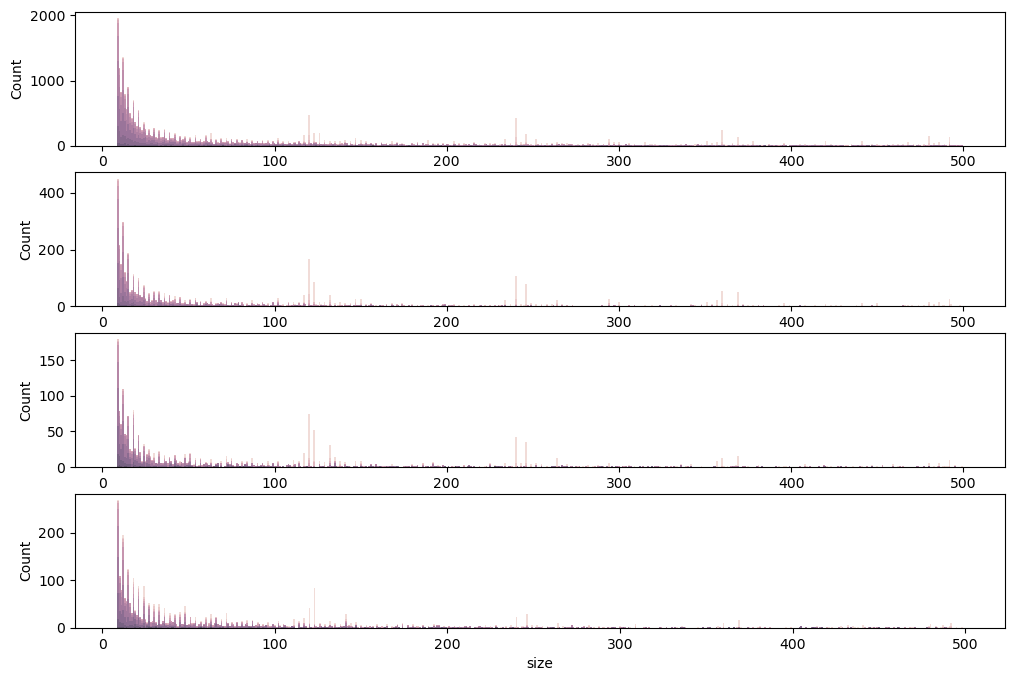

In [45]:
fig, axs = plt.subplots(4,1,figsize=(12,8))

sns.histplot(
    data=df_all.query('source=="mrub" & size<500 & nb_rel_aln < 5 & canonical_ss == "C"'),
    x='size', hue='hamming_min', discrete=True, multiple='stack', linewidth=0, ax=axs[0], legend=False,
)

sns.histplot(
    data=df_all.query('source=="mrub" & size<500 & nb_rel_aln >= 5 & nb_rel_aln < 20 & canonical_ss == "C"'),
    x='size', hue='hamming_min', discrete=True, multiple='stack', linewidth=0, ax=axs[1], legend=False,
)

sns.histplot(
    data=df_all.query('source=="mrub" & size<500 & nb_rel_aln >= 20 & nb_rel_aln < 50 & canonical_ss == "C"'),
    x='size', hue='hamming_min', discrete=True, multiple='stack', linewidth=0, ax=axs[2], legend=False,
)

sns.histplot(
    data=df_all.query('source=="mrub" & size<500 & nb_rel_aln >= 50 & canonical_ss == "C"'),
    x='size', hue='hamming_min', discrete=True, multiple='stack', linewidth=0, ax=axs[3], legend=False,
)

The peaks at 120 and 123 bp are doubled at 240 and 246 bp, indicating that they are within repeat regions.

In [46]:
df_all.query(
    'source=="mrub" & size>100 & size<150 & nb_rel_aln >= 50 & canonical_ss == "C"'
)['size'].value_counts().head()

size
123    84
120    42
141    29
117    20
111    18
Name: count, dtype: int64

In [47]:
df_all.query(
    'source=="mrub" & size>200 & size<300 & nb_rel_aln >= 50 & canonical_ss == "C"'
)['size'].value_counts().head()

size
246    28
240    23
264    10
249     6
228     6
Name: count, dtype: int64

## Filtered splice junction metrics

Portcullis tool trains a random forest model to filter out spurious intron predictions.

We plotted the raw results above because the model is not designed for species that have zero or very few introns, so we want to examine the putative intron metrics empirically first.

Now we plot the filtered introns to see how the model fares.

Library `pneu` has too few predicted junctions for the filter step.

Interestingly many junctions in `cmer` pass the filter : but most of these have low coverage, as seen above when filtering by nb_rel_aln.

In [51]:
filt = {}
for sp in [i for i in candidates if i != 'pneu']:
    filt[sp] = pd.read_table(f"../portcullis/filter/{sp}.pass.junctions.tab", sep="\t")
    filt[sp]['size3n'] = filt[sp]['size'].apply(lambda x: x%3 == 0)
    filt[sp]['source'] = sp
df_filt = pd.concat(filt.values())
df_filt['hamming_min'] = df_filt[['hamming3p','hamming5p']].min(axis=1)

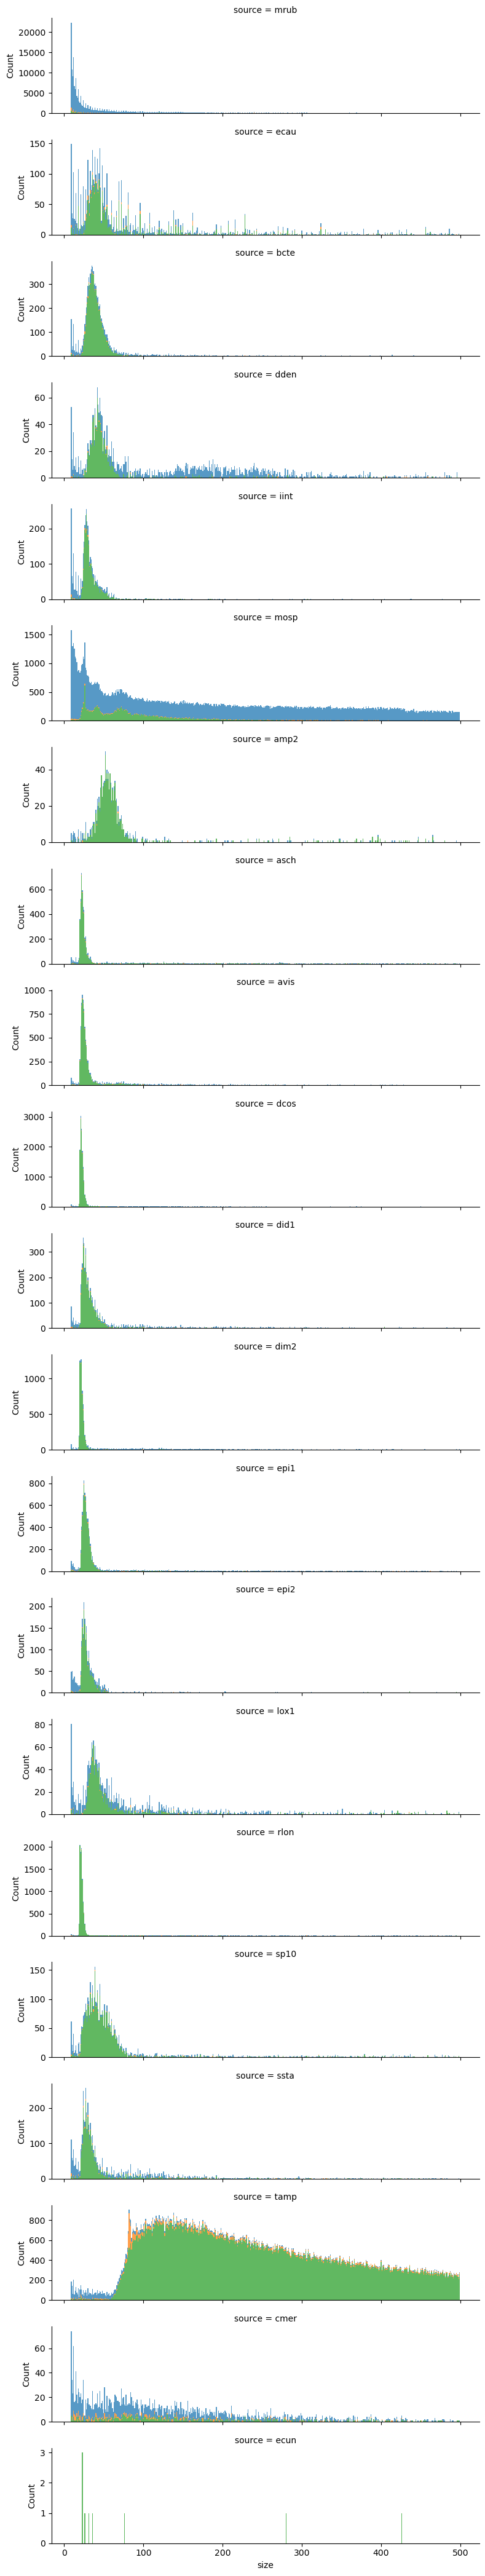

In [52]:
g = sns.FacetGrid(
    data=df_filt.query('size<500'),
    row='source',
    aspect=4, height=2, sharey='row',
)
g.map_dataframe(
    sns.histplot,
    x='size',
    hue='canonical_ss', hue_order=['N','S','C'],
    discrete=True, multiple='stack', linewidth=0,
)

g.savefig("portcullis_filtered.intron_size.by_canonical.pdf")
g.savefig("portcullis_filtered.intron_size.by_canonical.png")